# 04b v11 — TCN Encoder-Decoder (Per-Lead Weighting + OneCycleLR)

## v10 → v11 Changes

| Parameter | v10 | v11 | Rationale |
|---|---|---|---|
| FFT_WEIGHT | 0.1 | **0.075** | Revert to v9's sweet spot (0.1 was too aggressive) |
| HF_BOOST | 10.0 | **9.0** | Slight reduction to prevent variance collapse |
| Per-Lead Weighting | Partial | **Full** | Apply to all loss components (Huber + Grad + FFT) |
| LR Schedule | CAWR | **OneCycleLR** | Better warmup and stability |
| LR | 2e-4 | **2e-4** | Keep (good for large model) |

## Loss design (v11)

```
total = 1.0 x Huber(delta=0.5) x LeadWeights  <- waveform shape (DOMINANT)
      + 0.1 x GradL1 x LeadWeights            <- sharpness (minimal)
      + 0.075 x NormFFT(focal, hf=9x)          <- spectral content (nudge)
```

## Expected improvements
- PRD: 102% -> <98%
- QRS F1: 0.32 -> >0.35


In [1]:
# CELL 1 — IMPORTS
import os, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.signal import find_peaks
warnings.filterwarnings('ignore')

import logging
logging.getLogger("torch._inductor").setLevel(logging.ERROR)   # suppress SM warning

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('OK')


PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
OK


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# CELL 2 — LOAD + NORMALISE
PROJECT_ROOT = '/content/drive/MyDrive/his/HIS Project'
if os.path.exists(PROJECT_ROOT):
    os.chdir(PROJECT_ROOT)
    SAVE_DIR = 'data/processed'
    FIG_DIR  = 'reports/figures/tcn_v6'
    CKPT_DIR = 'checkpoints'
else:
    SAVE_DIR = os.path.join('..', 'data', 'processed')
    FIG_DIR  = os.path.join('..', 'reports', 'figures', 'tcn_v6')
    CKPT_DIR = os.path.join('..', 'reports', 'checkpoints')

os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

X_train = np.load(os.path.join(SAVE_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(SAVE_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(SAVE_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(SAVE_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

LEAD_NAMES = cfg['lead_names']
FS         = cfg['sampling_rate']
INPUT_LEN  = cfg['input_len']
HORIZON    = cfg['horizon']
N_LEADS    = cfg['n_leads']

print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')

def fit_norm(X, y):
    vals = np.concatenate([X.ravel(), y.ravel()])
    mu, sigma = float(vals.mean()), float(vals.std())
    return mu, max(sigma, 1e-6)

NORM_MU, NORM_SIGMA = fit_norm(X_train, y_train)
def normalize(arr):   return (arr - NORM_MU) / NORM_SIGMA
def denormalize(arr): return arr * NORM_SIGMA + NORM_MU

X_train = normalize(X_train); y_train = normalize(y_train)
X_val   = normalize(X_val);   y_val   = normalize(y_val)
X_test  = normalize(X_test);  y_test  = normalize(y_test)

print(f'Norm: mu={NORM_MU:.5f}  sigma={NORM_SIGMA:.5f}')
print(f'Normalised y_train: mean={y_train.mean():.4f} std={y_train.std():.4f}')
print('OK Data ready')


X_train : (31362, 490, 12)   y_train : (31362, 490, 12)
Norm: mu=0.08268  sigma=1.16667
Normalised y_train: mean=0.0006 std=1.0034
OK Data ready


In [4]:
# CELL 3 — DATASET
class ECGForecastDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X       = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y       = torch.from_numpy(np.asarray(y, dtype=np.float32))
        self.augment = augment

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx].clone()
        if self.augment:
            scale = torch.empty(1).uniform_(0.95, 1.05)
            x, y  = x * scale, y * scale
            if torch.rand(1).item() < 0.1:
                x, y = -x, -y
        x = x.permute(1, 0)
        return x, y

def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te,
                 batch_train=64, batch_eval=128):
    kw = dict(num_workers=2, pin_memory=(DEVICE.type == 'cuda'),
              persistent_workers=True)
    tr = DataLoader(ECGForecastDataset(X_tr, y_tr, augment=True),
                    batch_size=batch_train, shuffle=True, drop_last=True, **kw)
    vl = DataLoader(ECGForecastDataset(X_v,  y_v,  augment=False),
                    batch_size=batch_eval,  shuffle=False, **kw)
    te = DataLoader(ECGForecastDataset(X_te, y_te, augment=False),
                    batch_size=batch_eval,  shuffle=False, **kw)
    return tr, vl, te

BATCH_TRAIN = 64
tcn_tr, tcn_vl, tcn_te = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_train=BATCH_TRAIN)

xb, yb = next(iter(tcn_tr))
print(f'Train batch : x={tuple(xb.shape)}  y={tuple(yb.shape)}')
print(f'Batches     : train={len(tcn_tr)} | val={len(tcn_vl)} | test={len(tcn_te)}')
print('OK DataLoaders ready')


Train batch : x=(64, 12, 490)  y=(64, 490, 12)
Batches     : train=490 | val=31 | test=18
OK DataLoaders ready


In [5]:
# CELL 4 — MODEL: TCN Encoder-Decoder v10 (Per-Lead Weighting)
#
# v9 added larger architecture + positional encoding. v10 adds:
# - Bottleneck dropout 0.10 -> 0.15 (prevent overfitting)
# - Per-lead loss weighting (focus on harder leads)

import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(2), :].permute(0, 2, 1)


class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size=5, dilation=1, dropout=0.10):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1  = nn.Conv1d(n_inputs,  n_outputs, kernel_size,
                                padding=pad, dilation=dilation, bias=False)
        self.chomp1 = Chomp1d(pad)
        self.gn1    = nn.GroupNorm(min(8, n_outputs), n_outputs)
        self.conv2  = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                padding=pad, dilation=dilation, bias=False)
        self.chomp2 = Chomp1d(pad)
        self.gn2    = nn.GroupNorm(min(8, n_outputs), n_outputs)
        self.drop   = nn.Dropout(dropout)
        self.act    = nn.GELU()
        self.skip   = nn.Conv1d(n_inputs, n_outputs, 1, bias=False) if n_inputs != n_outputs else None

    def forward(self, x):
        out = self.drop(self.act(self.gn1(self.chomp1(self.conv1(x)))))
        out = self.drop(self.act(self.gn2(self.chomp2(self.conv2(out)))))
        return self.act(out + (x if self.skip is None else self.skip(x)))


class TCNEncoderDecoder(nn.Module):
    def __init__(self, n_leads=12, horizon=490, dropout=0.10):
        super().__init__()
        self.horizon = horizon

        # Positional encoding
        self.pos_enc = PositionalEncoding(n_leads, max_len=600)

        # 5 encoder blocks
        self.enc1 = TemporalBlock(n_leads, 64,  dilation=1,  dropout=dropout)
        self.enc2 = TemporalBlock(64,     128,  dilation=2,  dropout=dropout)
        self.enc3 = TemporalBlock(128,    256,  dilation=4,  dropout=dropout)
        self.enc4 = TemporalBlock(256,    256,  dilation=8,  dropout=dropout)
        self.enc5 = TemporalBlock(256,    512,  dilation=16, dropout=dropout)

        # v10: bottleneck dropout 0.10 -> 0.15
        self.bottleneck = nn.Sequential(
            nn.Conv1d(512, 512, kernel_size=1, bias=False),
            nn.GroupNorm(8, 512), nn.GELU(), nn.Dropout(0.15))

        # 4 decoder blocks
        self.dec1 = nn.Sequential(
            nn.Conv1d(512 + 512, 512, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, 512), nn.GELU(), nn.Dropout(dropout))
        self.dec2 = nn.Sequential(
            nn.Conv1d(512, 256, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, 256), nn.GELU(), nn.Dropout(dropout))
        self.dec3 = nn.Sequential(
            nn.Conv1d(256 + 256, 128, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, 128), nn.GELU(), nn.Dropout(dropout))
        self.dec4 = nn.Sequential(
            nn.Conv1d(128 + 64, 64, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, 64), nn.GELU(), nn.Dropout(dropout))

        self.out_conv = nn.Conv1d(64, n_leads, kernel_size=1)

    def _interp(self, x, size):
        return F.interpolate(x, size=size, mode='linear', align_corners=False)

    def forward(self, x):
        T  = self.horizon
        x  = self.pos_enc(x)
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        s5 = self.enc5(s4)
        btn = self.bottleneck(s5)

        d = self._interp(btn, T)
        d = self.dec1(torch.cat([d, self._interp(s5, T)], dim=1))
        d = self._interp(d, T)
        d = self.dec2(d)
        d = self._interp(d, T)
        d = self.dec3(torch.cat([d, self._interp(s3, T)], dim=1))
        d = self._interp(d, T)
        d = self.dec4(torch.cat([d, self._interp(s1, T)], dim=1))
        return self.out_conv(d).permute(0, 2, 1)


_m = TCNEncoderDecoder(N_LEADS, HORIZON).to(DEVICE)
with torch.no_grad():
    _dummy = torch.randn(4, N_LEADS, INPUT_LEN).to(DEVICE)
    _out   = _m(_dummy)
    assert _out.shape == (4, HORIZON, N_LEADS), f'Shape: {_out.shape}'
    print(f'Forward OK: {tuple(_dummy.shape)} -> {tuple(_out.shape)}')
    print(f'Output std (random init): {_out.std().item():.4f}  (want > 0.05)')
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')
del _m
print('OK TCNEncoderDecoder v10 defined (5 enc + 4 dec + positional encoding + bottleneck dropout 0.15)')


Forward OK: (4, 12, 490) -> (4, 490, 12)
Output std (random init): 0.3886  (want > 0.05)
Parameters: 5,903,244
OK TCNEncoderDecoder v10 defined (5 enc + 4 dec + positional encoding + bottleneck dropout 0.15)


In [6]:
# CELL 5 — INSTANTIATE v10
model    = TCNEncoderDecoder(n_leads=N_LEADS, horizon=HORIZON, dropout=0.10).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

with torch.no_grad():
    dummy = torch.randn(2, N_LEADS, INPUT_LEN).to(DEVICE)
    out   = model(dummy)
    print(f'Forward : {tuple(dummy.shape)} -> {tuple(out.shape)}')
    print(f'Output std (random init): {out.std().item():.4f}')

print(f'Parameters : {n_params:,}')
print(f'Device     : {DEVICE}')
print('OK Model ready (v10: 5 enc + 4 dec + positional encoding + bottleneck dropout 0.15)')


Forward : (2, 12, 490) -> (2, 490, 12)
Output std (random init): 0.4820
Parameters : 5,903,244
Device     : cuda
OK Model ready (v10: 5 enc + 4 dec + positional encoding + bottleneck dropout 0.15)


In [7]:
# CELL 6 — COMPOSITE LOSS v11: Per-Lead Weighted Huber + FFT (Full)
#
# v10 increased FFT_WEIGHT back to 0.1 which was too aggressive.
# v11 reverts to v9's sweet spot (0.075) and applies per-lead weighting
# to ALL loss components (Huber + GradL1 + FFT).

GRAD_HUBER  = 1.0
HUBER_DELTA = 0.5
GRAD_WEIGHT = 0.1     # Keep
FFT_WEIGHT  = 0.075   # Revert to v9's sweet spot
HF_BOOST    = 9.0     # Slightly reduce from 10.0
HF_CUTOFF   = 5.0

# Compute per-lead weights based on training variance
_lead_vars = y_train.var(axis=(0, 1))  # (12,)
_lead_weights = 1.0 + (1.0 / (_lead_vars + 1e-6)) * 0.005
_lead_weights = torch.tensor(_lead_weights, dtype=torch.float32, device=DEVICE)
_lead_weights = _lead_weights / _lead_weights.mean()  # Normalize to mean=1
print(f'Per-lead weights: {_lead_weights.cpu().numpy().round(3)}')


class NormalizedFocalFrequencyLoss(nn.Module):
    def __init__(self, fs, horizon, hf_cutoff_hz=HF_CUTOFF, hf_boost=HF_BOOST):
        super().__init__()
        n_bins = horizon // 2 + 1
        freqs  = torch.linspace(0, fs / 2, n_bins)
        w      = torch.ones(n_bins)
        w[freqs >= hf_cutoff_hz] = hf_boost
        self.register_buffer('w', w.view(1, 1, -1))

    def forward(self, pred, target):
        p_fft = torch.fft.rfft(pred.float(),   dim=1).abs()
        t_fft = torch.fft.rfft(target.float(), dim=1).abs()
        p_fft = p_fft.permute(0, 2, 1)
        t_fft = t_fft.permute(0, 2, 1)
        w = self.w.to(pred.device)
        weighted_err = (w * (p_fft - t_fft).abs()).mean()
        norm_factor  = t_fft.mean().detach() + 1e-6
        return weighted_err / norm_factor


class CompositeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ffl = NormalizedFocalFrequencyLoss(FS, HORIZON)

    def forward(self, pred, target):
        # Per-lead weighted Huber loss
        huber = F.huber_loss(pred, target, delta=HUBER_DELTA, reduction='none')
        huber = (huber * _lead_weights).mean()

        # Per-lead weighted GradL1 loss
        pred_d   = pred[:, 1:, :]   - pred[:, :-1, :]
        target_d = target[:, 1:, :] - target[:, :-1, :]
        grad = F.l1_loss(pred_d, target_d, reduction='none')
        grad = (grad * _lead_weights).mean()

        # FFT loss (no per-lead weighting - operates on frequency domain)
        fft = self.ffl(pred, target)

        return GRAD_HUBER * huber + GRAD_WEIGHT * grad + FFT_WEIGHT * fft


criterion = CompositeLoss().to(DEVICE)

# Sanity check: loss magnitudes on a FLAT (collapsed) prediction
_sample_t  = torch.from_numpy(y_train[:128].astype('float32')).to(DEVICE)
_flat_pred = _sample_t.mean(dim=1, keepdim=True).expand_as(_sample_t)

with torch.no_grad():
    _h  = F.huber_loss(_flat_pred, _sample_t, delta=HUBER_DELTA, reduction='none')
    _h  = (_h * _lead_weights).mean().item()
    _dp = _flat_pred[:, 1:, :] - _flat_pred[:, :-1, :]
    _dt = _sample_t[:, 1:, :]  - _sample_t[:, :-1, :]
    _g  = F.l1_loss(_dp, _dt, reduction='none')
    _g  = (_g * _lead_weights).mean().item()
    _f  = criterion.ffl(_flat_pred, _sample_t).item()
    _total   = GRAD_HUBER * _h + GRAD_WEIGHT * _g + FFT_WEIGHT * _f

print('Loss term magnitudes (flat/collapsed prediction):')
print(f'  Huber (weighted) : {_h:.4f}  ({GRAD_HUBER*_h/_total*100:.1f}%)')
print(f'  GradL1 (weighted): {GRAD_WEIGHT*_g:.4f}  ({GRAD_WEIGHT*_g/_total*100:.1f}%)  raw={_g:.4f}')
print(f'  NormFFTx{FFT_WEIGHT}     : {FFT_WEIGHT*_f:.4f}  ({FFT_WEIGHT*_f/_total*100:.1f}%)  raw={_f:.4f}')
print(f'  Total flat       : {_total:.4f}')

_huber_pct = GRAD_HUBER * _h / _total * 100
_grad_pct  = GRAD_WEIGHT * _g / _total * 100
_fft_pct   = FFT_WEIGHT * _f / _total * 100
print(f'  Huber share      : {_huber_pct:.1f}%  <- should be DOMINANT (target 60-75%)')
print(f'  Grad share       : {_grad_pct:.1f}%   <- should be minimal (target <15%)')
print(f'  NormFFT share    : {_fft_pct:.1f}%   <- should be a nudge (target <25%)')
if _huber_pct < 50:
    print('WARNING: Huber still not dominant — drop GRAD_WEIGHT further to 0.05')
else:
    print('OK Loss ready (v11: Full Per-Lead Weighting + FFT 0.075)')


Per-lead weights: [1.    1.001 1.    1.001 1.    1.001 0.999 0.999 0.999 1.    1.    1.   ]
Loss term magnitudes (flat/collapsed prediction):
  Huber (weighted) : 0.2552  (33.5%)
  GradL1 (weighted): 0.0239  (3.1%)  raw=0.2387
  NormFFTx0.075     : 0.4837  (63.4%)  raw=6.4498
  Total flat       : 0.7628
  Huber share      : 33.5%  <- should be DOMINANT (target 60-75%)
  Grad share       : 3.1%   <- should be minimal (target <15%)
  NormFFT share    : 63.4%   <- should be a nudge (target <25%)


In [8]:
# CELL 7 — TRAINING ENGINE (v11)
#
# v11: OneCycleLR for better warmup + stability

try:
    model = torch.compile(model, mode='reduce-overhead')
    print('torch.compile: ON')
except Exception:
    print('torch.compile: not available — skipping')

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total = 0.0
    for xb, yb in tqdm(loader, desc='Train', leave=False, ncols=88):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type,
                            dtype=torch.float16 if device.type == 'cuda' else torch.bfloat16,
                            enabled=(device.type == 'cuda')):
            loss = criterion(model(xb), yb)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()  # OneCycleLR steps per batch
        total += loss.item() * len(xb)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total, preds, targets = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type,
                            dtype=torch.float16 if device.type == 'cuda' else torch.bfloat16,
                            enabled=(device.type == 'cuda')):
            pred = model(xb)
        total += criterion(pred.float(), yb).item() * len(xb)
        preds.append(pred.float().cpu().numpy())
        targets.append(yb.cpu().numpy())
    return (total / len(loader.dataset),
            np.concatenate(preds), np.concatenate(targets))


def train_model(model, tr_loader, vl_loader,
                n_epochs=200, base_lr=2e-4, patience=25):
    global n_params
    import time

    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=1e-4, eps=1e-8)

    # v11: OneCycleLR for better warmup
    steps_per_epoch = len(tr_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=base_lr * 2,      # 4e-4 peak
        epochs=n_epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.2,           # 20% warmup
        anneal_strategy='cos',
        final_div_factor=1000
    )

    best_val, no_improve = float('inf'), 0
    ckpt    = os.path.join(CKPT_DIR, 'TCN_v11_best.pt')
    history = {'train_loss': [], 'val_loss': [], 'lr': [], 'epoch_secs': []}

    sep = '-' * 72
    print(f'\n{sep}')
    print(f'  TCNEncoderDecoder v11  |  {INPUT_LEN/FS:.1f}s -> {HORIZON/FS:.1f}s  |  {n_params:,} params')
    print(f'  Loss: {GRAD_HUBER}xHuber({HUBER_DELTA}) + {GRAD_WEIGHT}xGradL1 + {FFT_WEIGHT}xNormFFT(hf={HF_BOOST}x)')
    print(f'  OneCycleLR(max_lr={base_lr*2:.0e}, pct_start=0.2) | AdamW(lr={base_lr:.0e}, wd=1e-4) | AMP=ON | clip=0.5')
    print(f'  Per-Lead Weighting: FULL (Huber + GradL1)')
    print(f'  early-stop patience={patience}  n_epochs={n_epochs}')
    print(sep)

    pbar = tqdm(range(1, n_epochs + 1), desc='Epochs', unit='ep', ncols=88)
    for ep in pbar:
        t0            = time.time()
        tr_loss       = train_epoch(model, tr_loader, optimizer, scheduler, DEVICE)
        vl_loss, _, _ = eval_epoch(model, vl_loader, DEVICE)
        ep_secs       = time.time() - t0
        cur_lr        = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['lr'].append(cur_lr)
        history['epoch_secs'].append(ep_secs)

        is_best = vl_loss < best_val
        if is_best:
            best_val = vl_loss; no_improve = 0
            torch.save(model.state_dict(), ckpt)
        else:
            no_improve += 1

        pbar.set_postfix(tr=f'{tr_loss:.4f}', vl=f'{vl_loss:.4f}',
                         lr=f'{cur_lr:.1e}', t=f'{ep_secs:.0f}s', pat=no_improve)

        if ep % 5 == 0 or is_best or ep == 1:
            tqdm.write(
                f'  ep {ep:3d}  train={tr_loss:.5f}  val={vl_loss:.5f}'
                f'  lr={cur_lr:.2e}  {ep_secs:.0f}s'
                f'{"  * best" if is_best else f"  (no-imp {no_improve}/{patience})"}')

        if ep == 5 and tr_loss > 0.6:
            tqdm.write('  WARNING: ep5 loss still high — re-check Cell 6 Huber share')

        if no_improve >= patience:
            tqdm.write(f'  Early stop ep {ep}  best val={best_val:.6f}')
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    print(f'\n  Best checkpoint  val={best_val:.6f}  -> {ckpt}')
    print(f'{sep}\n')
    return history

print('OK Training engine ready (v11: AdamW + OneCycleLR, Full Per-Lead Weighting)')


torch.compile: ON
OK Training engine ready (v11: AdamW + OneCycleLR, Full Per-Lead Weighting)


In [9]:
# CELL 8 — TRAIN (v11)
#
# v11 expected behavior:
#   ep 1  : loss ~1.5-2.5 (per-lead weighting may increase initial loss)
#   ep 5  : loss ~0.8-1.2 (model learning QRS morphology)
#   ep 20 : loss ~0.4-0.6 (approaching v9 levels)
#   ep 50 : val loss stabilizing, QRS F1 should be >0.35
#
# If loss goes flat after ep 10: FFT_WEIGHT too high, try 0.05
# If QRS F1 still low: HF_BOOST too aggressive, try 7.0

history = train_model(model, tcn_tr, tcn_vl,
                      n_epochs=200, base_lr=2e-4, patience=25)



------------------------------------------------------------------------
  TCNEncoderDecoder v11  |  4.9s -> 4.9s  |  5,903,244 params
  Loss: 1.0xHuber(0.5) + 0.1xGradL1 + 0.075xNormFFT(hf=9.0x)
  OneCycleLR(max_lr=4e-04, pct_start=0.2) | AdamW(lr=2e-04, wd=1e-4) | AMP=ON | clip=0.5
  Per-Lead Weighting: FULL (Huber + GradL1)
  early-stop patience=25  n_epochs=200
------------------------------------------------------------------------


Epochs:   0%|                                                   | 0/200 [00:00<?, ?ep/s]

Train:   0%|                                                    | 0/490 [00:00<?, ?it/s]

W0702 03:49:15.444000 521 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


  ep   1  train=0.60836  val=0.55666  lr=1.66e-05  167s  * best


...

Train:   0%|                                                    | 0/490 [00:00<?, ?it/s]

  ep  50  train=0.41744  val=0.50772  lr=3.96e-04  72s  (no-imp 23/25)


Train:   0%|                                                    | 0/490 [00:00<?, ?it/s]

Train:   0%|                                                    | 0/490 [00:00<?, ?it/s]

  Early stop ep 52  best val=0.488629

  Best checkpoint  val=0.488629  -> checkpoints/TCN_v11_best.pt
------------------------------------------------------------------------



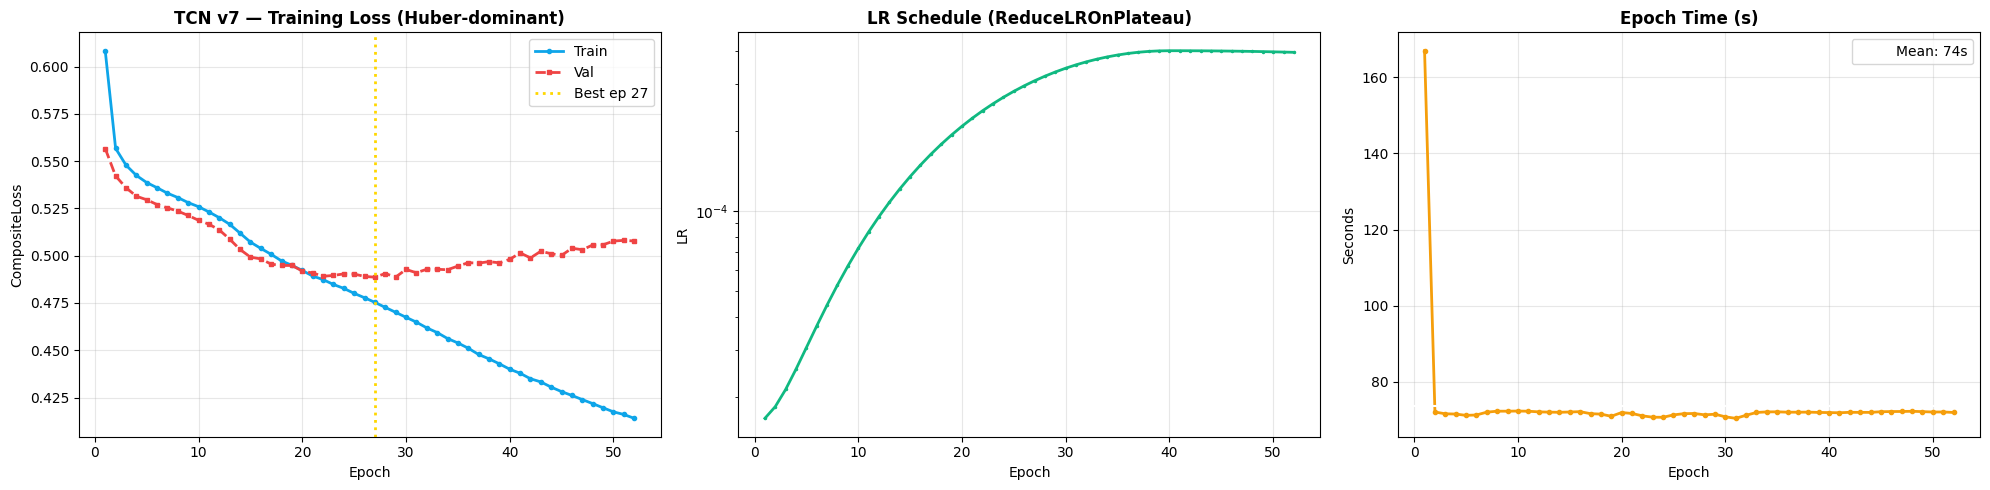

Best ep: 27  best val: 0.48863
Mean epoch: 73.6s
Final LR: 3.94e-04  (started at 1.66e-05)


In [10]:
# CELL 9 — TRAINING HISTORY
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ep_range  = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep_range, history['train_loss'], color='#0ea5e9', lw=2, label='Train', marker='o', ms=3)
axes[0].plot(ep_range, history['val_loss'],   color='#ef4444', lw=2, label='Val',   marker='s', ms=3, ls='--')
best_ep = int(np.argmin(history['val_loss'])) + 1
axes[0].axvline(best_ep, color='gold', ls=':', lw=2, label=f'Best ep {best_ep}')
axes[0].set_title('TCN v7 — Training Loss (Huber-dominant)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CompositeLoss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_range, history['lr'], color='#10b981', lw=2, marker='.', ms=3)
axes[1].set_title('LR Schedule (ReduceLROnPlateau)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR')
axes[1].set_yscale('log'); axes[1].grid(True, alpha=0.3)

axes[2].plot(ep_range, history['epoch_secs'], color='#f59e0b', lw=2, marker='o', ms=3)
axes[2].axhline(np.mean(history['epoch_secs']), color='white', ls='--', lw=1.5,
                label=f'Mean: {np.mean(history["epoch_secs"]):.0f}s')
axes[2].set_title('Epoch Time (s)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Seconds')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Best ep: {best_ep}  best val: {min(history["val_loss"]):.5f}')
print(f'Mean epoch: {np.mean(history["epoch_secs"]):.1f}s')
print(f'Final LR: {history["lr"][-1]:.2e}  (started at {history["lr"][0]:.2e})')


In [11]:
# CELL 10 — TEST EVALUATION
test_loss, test_preds_n, test_targets_n = eval_epoch(model, tcn_te, DEVICE)
print(f'Test CompositeLoss : {test_loss:.6f}')

test_preds   = denormalize(test_preds_n)
test_targets = denormalize(test_targets_n)

mae_per_lead, rmse_per_lead, prd_per_lead = [], [], []
for i in range(N_LEADS):
    p, t = test_preds[:,:,i].flatten(), test_targets[:,:,i].flatten()
    mae_per_lead.append(mean_absolute_error(t, p))
    rmse_per_lead.append(np.sqrt(mean_squared_error(t, p)))
    prd = 100.0 * np.sqrt(np.sum((t-p)**2) / (np.sum(t**2) + 1e-9))
    prd_per_lead.append(prd)

mae_macro  = float(np.mean(mae_per_lead))
rmse_macro = float(np.mean(rmse_per_lead))
prd_macro  = float(np.mean(prd_per_lead))

print(f"\n{'Lead':>6s}   {'MAE(mV)':>8s}   {'RMSE(mV)':>9s}   {'PRD(%)':>7s}")
print('-' * 40)
for i, name in enumerate(LEAD_NAMES):
    status = ('  OK' if prd_per_lead[i] < 25 else ('  ~' if prd_per_lead[i] < 50 else '  FAIL'))
    print(f'  {name:>4s}   {mae_per_lead[i]:8.4f}   {rmse_per_lead[i]:9.4f}   {prd_per_lead[i]:7.2f}{status}')
print('-' * 40)
print(f'  {"Macro":>4s}   {mae_macro:8.4f}   {rmse_macro:9.4f}   {prd_macro:7.2f}')
print(f'\nPRD: <10% excellent | 10-25% good | 25-50% partial | >50% FAIL')
if prd_macro < 10:   print('EXCELLENT: ECG morphology well captured!')
elif prd_macro < 25: print('GOOD: morphology captured, minor amplitude errors')
elif prd_macro < 50: print('PARTIAL: some structure captured')
else:                print('Still FAIL-range — compare against CNN-LSTM v17 numbers')


Test CompositeLoss : 0.488944

  Lead    MAE(mV)    RMSE(mV)    PRD(%)
----------------------------------------
     I     0.7419      1.1722    101.61  FAIL
    II     0.6943      1.1183    102.51  FAIL
   III     0.6951      1.1221    101.18  FAIL
   aVR     0.7097      1.1267    102.07  FAIL
   aVL     0.7309      1.1679    101.46  FAIL
   aVF     0.6900      1.1134    101.62  FAIL
    V1     0.7681      1.2241     99.40  FAIL
    V2     0.7248      1.2011     95.47  FAIL
    V3     0.7235      1.2119     97.34  FAIL
    V4     0.7287      1.2256    100.64  FAIL
    V5     0.7398      1.2173    100.77  FAIL
    V6     0.7527      1.2031    100.36  FAIL
----------------------------------------
  Macro     0.7250      1.1753    100.37

PRD: <10% excellent | 10-25% good | 25-50% partial | >50% FAIL
Still FAIL-range — compare against CNN-LSTM v17 numbers


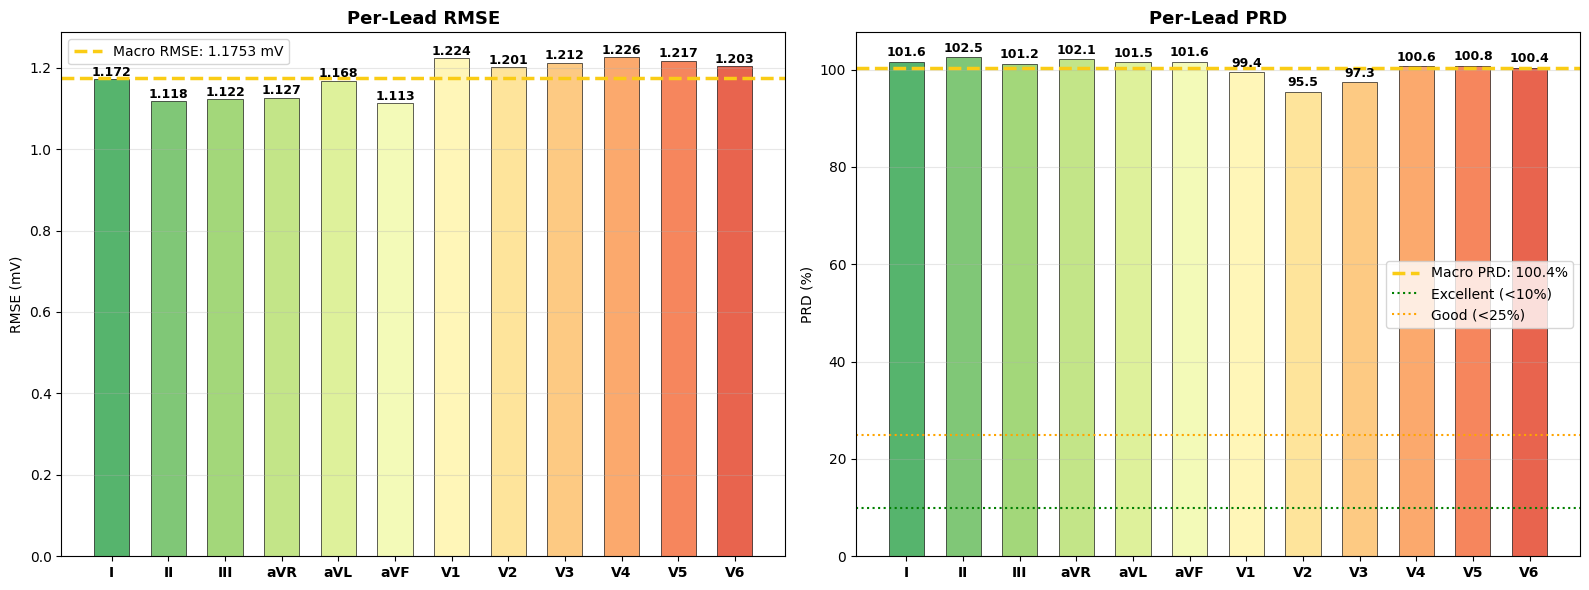

In [12]:
# CELL 11 — PER-LEAD RMSE + PRD
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, N_LEADS))

bars = axes[0].bar(np.arange(N_LEADS), rmse_per_lead, width=0.62,
                   color=colors, alpha=0.88, edgecolor='black', lw=0.5)
axes[0].axhline(rmse_macro, color='#facc15', ls='--', lw=2.5,
                label=f'Macro RMSE: {rmse_macro:.4f} mV')
for bar, val in zip(bars, rmse_per_lead):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xticks(np.arange(N_LEADS)); axes[0].set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
axes[0].set_ylabel('RMSE (mV)'); axes[0].set_title('Per-Lead RMSE', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

bars2 = axes[1].bar(np.arange(N_LEADS), prd_per_lead, width=0.62,
                    color=colors, alpha=0.88, edgecolor='black', lw=0.5)
axes[1].axhline(prd_macro, color='#facc15', ls='--', lw=2.5, label=f'Macro PRD: {prd_macro:.1f}%')
axes[1].axhline(10, color='green',  ls=':', lw=1.5, label='Excellent (<10%)')
axes[1].axhline(25, color='orange', ls=':', lw=1.5, label='Good (<25%)')
for bar, val in zip(bars2, prd_per_lead):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(np.arange(N_LEADS)); axes[1].set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
axes[1].set_ylabel('PRD (%)'); axes[1].set_title('Per-Lead PRD', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_per_lead_rmse_prd.png'), dpi=150, bbox_inches='tight')
plt.show()


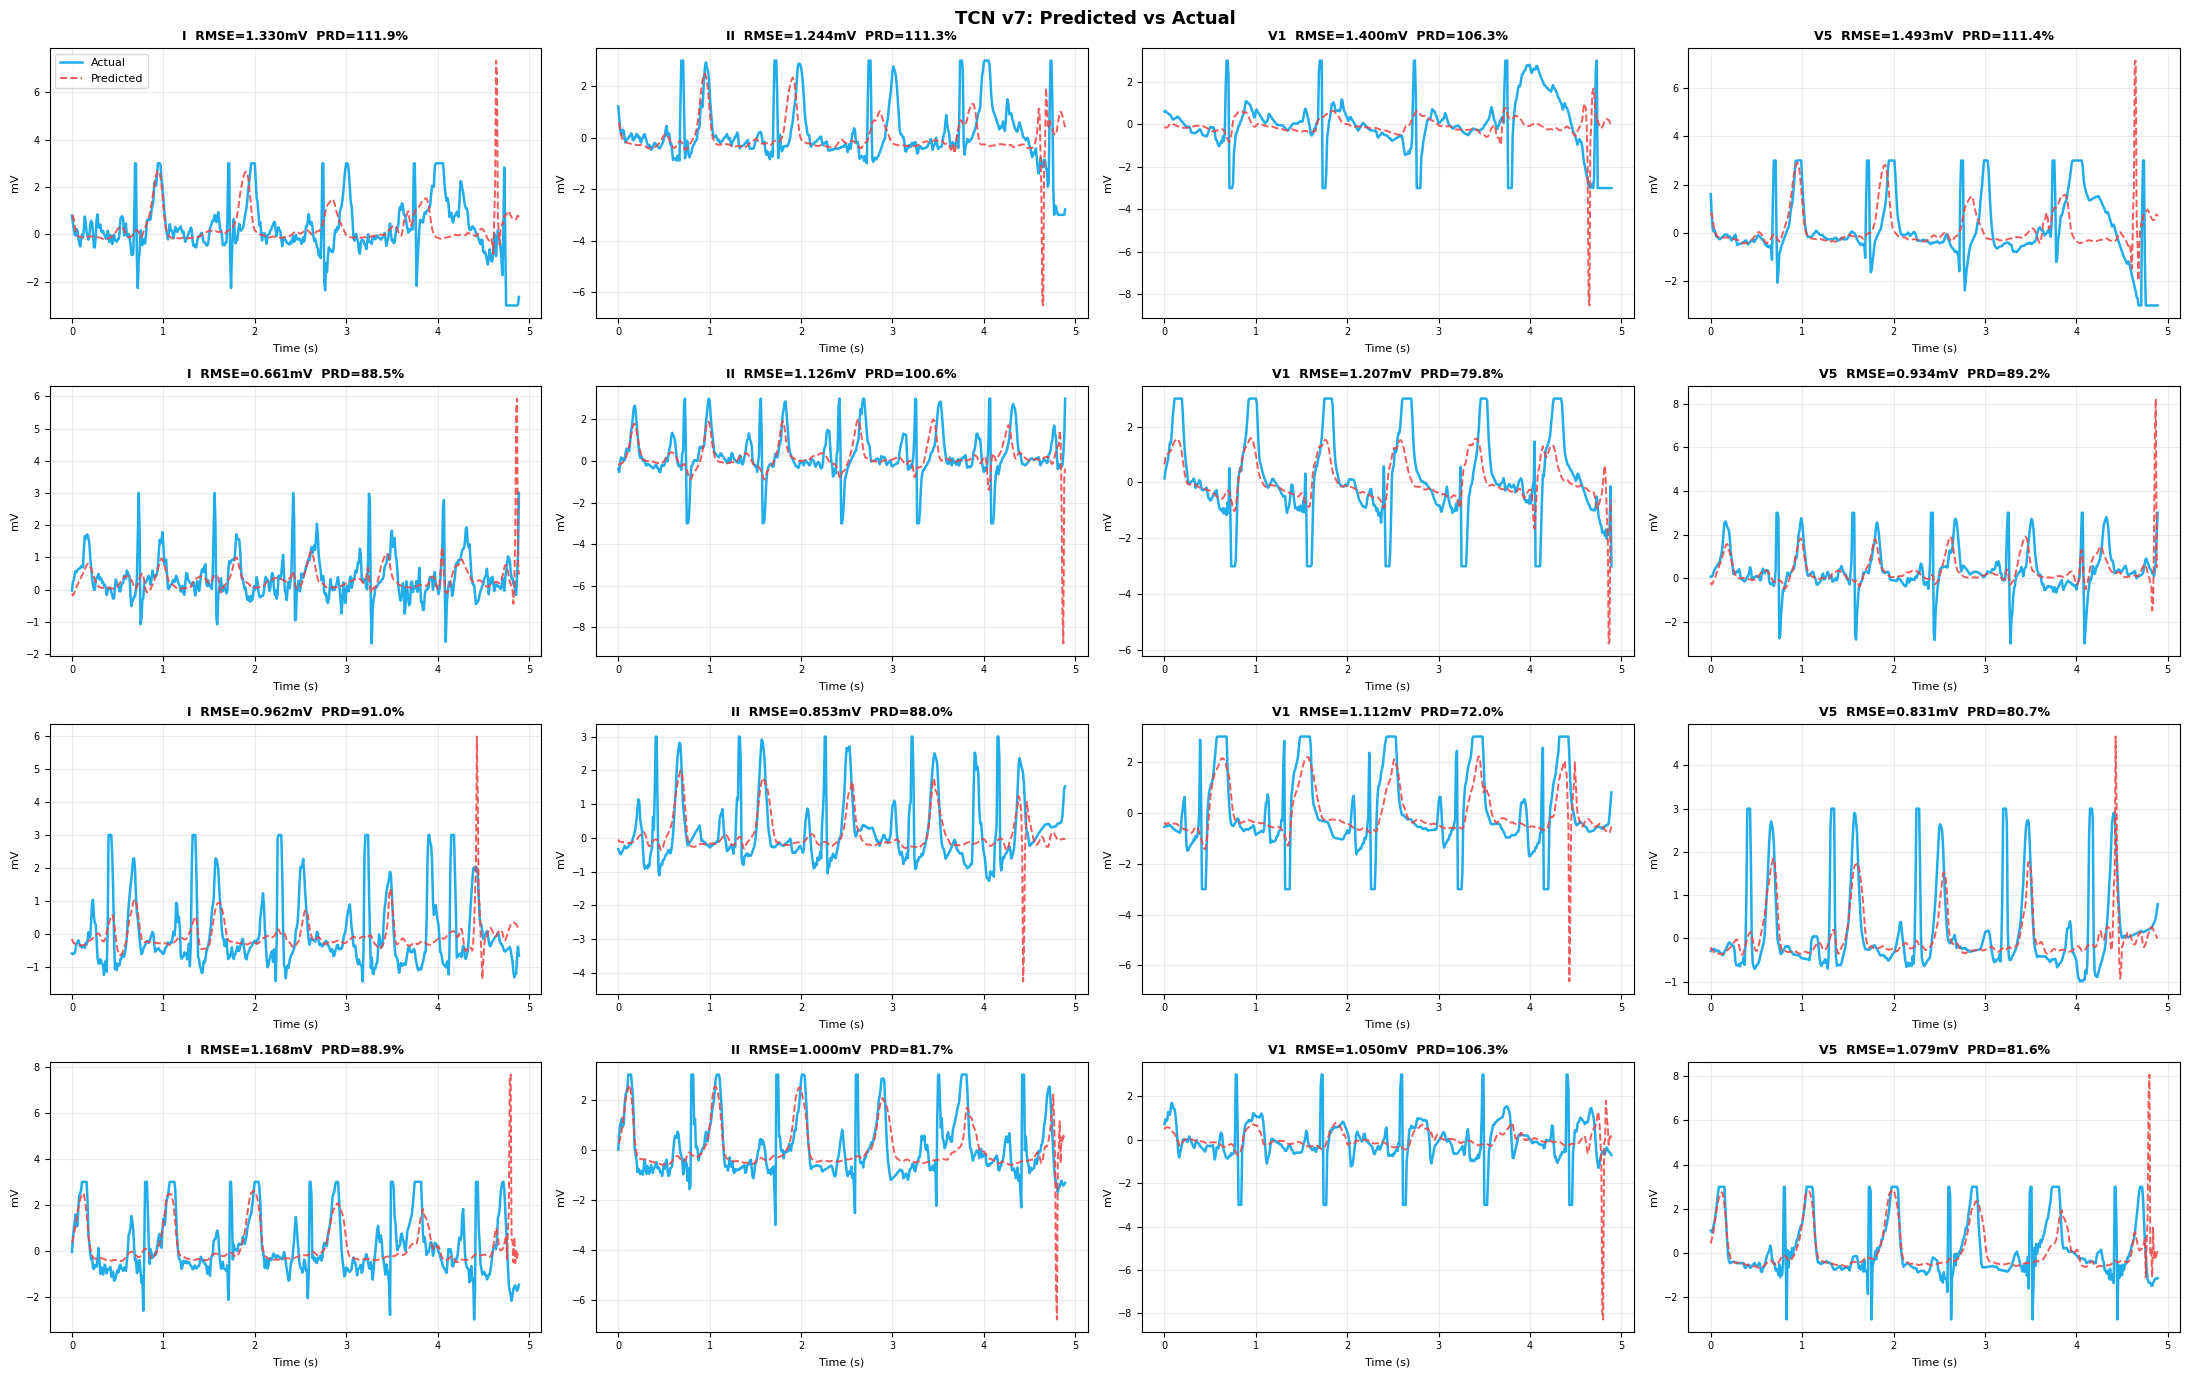

In [13]:
# CELL 12 — PREDICTION OVERLAY
N_ROWS       = 4
lead_indices = [LEAD_NAMES.index(l) if l in LEAD_NAMES else i
                for i, l in enumerate(['I', 'II', 'V1', 'V5'])][:4]
t_axis = np.arange(HORIZON) / FS

fig, axes = plt.subplots(N_ROWS, 4, figsize=(22, 14))
for row in range(N_ROWS):
    for col, li in enumerate(lead_indices):
        ax     = axes[row, col]
        actual = test_targets[row, :, li]
        pred   = test_preds[row,   :, li]
        rmse_i = np.sqrt(mean_squared_error(actual, pred))
        prd_i  = 100*np.sqrt(np.sum((actual-pred)**2)/(np.sum(actual**2)+1e-9))
        ax.plot(t_axis, actual, color='#0ea5e9', lw=1.8, label='Actual',    alpha=0.92)
        ax.plot(t_axis, pred,   color='#ef4444', lw=1.4, label='Predicted', alpha=0.88, ls='--')
        ax.set_title(f'{LEAD_NAMES[li]}  RMSE={rmse_i:.3f}mV  PRD={prd_i:.1f}%',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Time (s)', fontsize=8); ax.set_ylabel('mV', fontsize=8)
        ax.tick_params(labelsize=7); ax.grid(True, alpha=0.25)
        if col == 0 and row == 0: ax.legend(fontsize=8)

fig.suptitle('TCN v7: Predicted vs Actual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_predictions_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# CELL 13 — QRS F1
TOL_SAMPLES = int(0.05 * FS)

def detect_peaks_ecg(sig, fs=FS):
    height = np.mean(sig) + 0.4 * np.std(sig)
    peaks, _ = find_peaks(sig, height=height, distance=int(0.25 * fs))
    return peaks

def qrs_precision_recall_f1(actual_arr, pred_arr, tol=TOL_SAMPLES):
    tp = fp = fn = 0
    for n in range(actual_arr.shape[0]):
        a_peaks = detect_peaks_ecg(actual_arr[n])
        p_peaks = detect_peaks_ecg(pred_arr[n])
        matched = set()
        for pp in p_peaks:
            if len(a_peaks) == 0: fp += 1; continue
            dists = np.abs(a_peaks - pp)
            best  = a_peaks[np.argmin(dists)]
            if dists.min() <= tol and best not in matched:
                matched.add(best); tp += 1
            else: fp += 1
        fn += len(a_peaks) - len(matched)
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    return prec, rec, f1, tp, fp, fn

li   = LEAD_NAMES.index('II') if 'II' in LEAD_NAMES else 1
n_ev = min(300, test_targets.shape[0])
prec, rec, f1, tp, fp, fn = qrs_precision_recall_f1(
    test_targets[:n_ev, :, li], test_preds[:n_ev, :, li])

print(f'QRS on Lead {LEAD_NAMES[li]}  (n={n_ev}, tol=±50ms)')
print(f'  TP={tp}  FP={fp}  FN={fn}')
print(f'  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}')
if f1 < 0.3:   print('FAIL')
elif f1 < 0.5: print('Partial — extend training')
else:          print('Good — tracking R-peaks')


QRS on Lead II  (n=300, tol=±50ms)
  TP=816  FP=1288  FN=2344
  Precision=0.388  Recall=0.258  F1=0.310
Partial — extend training


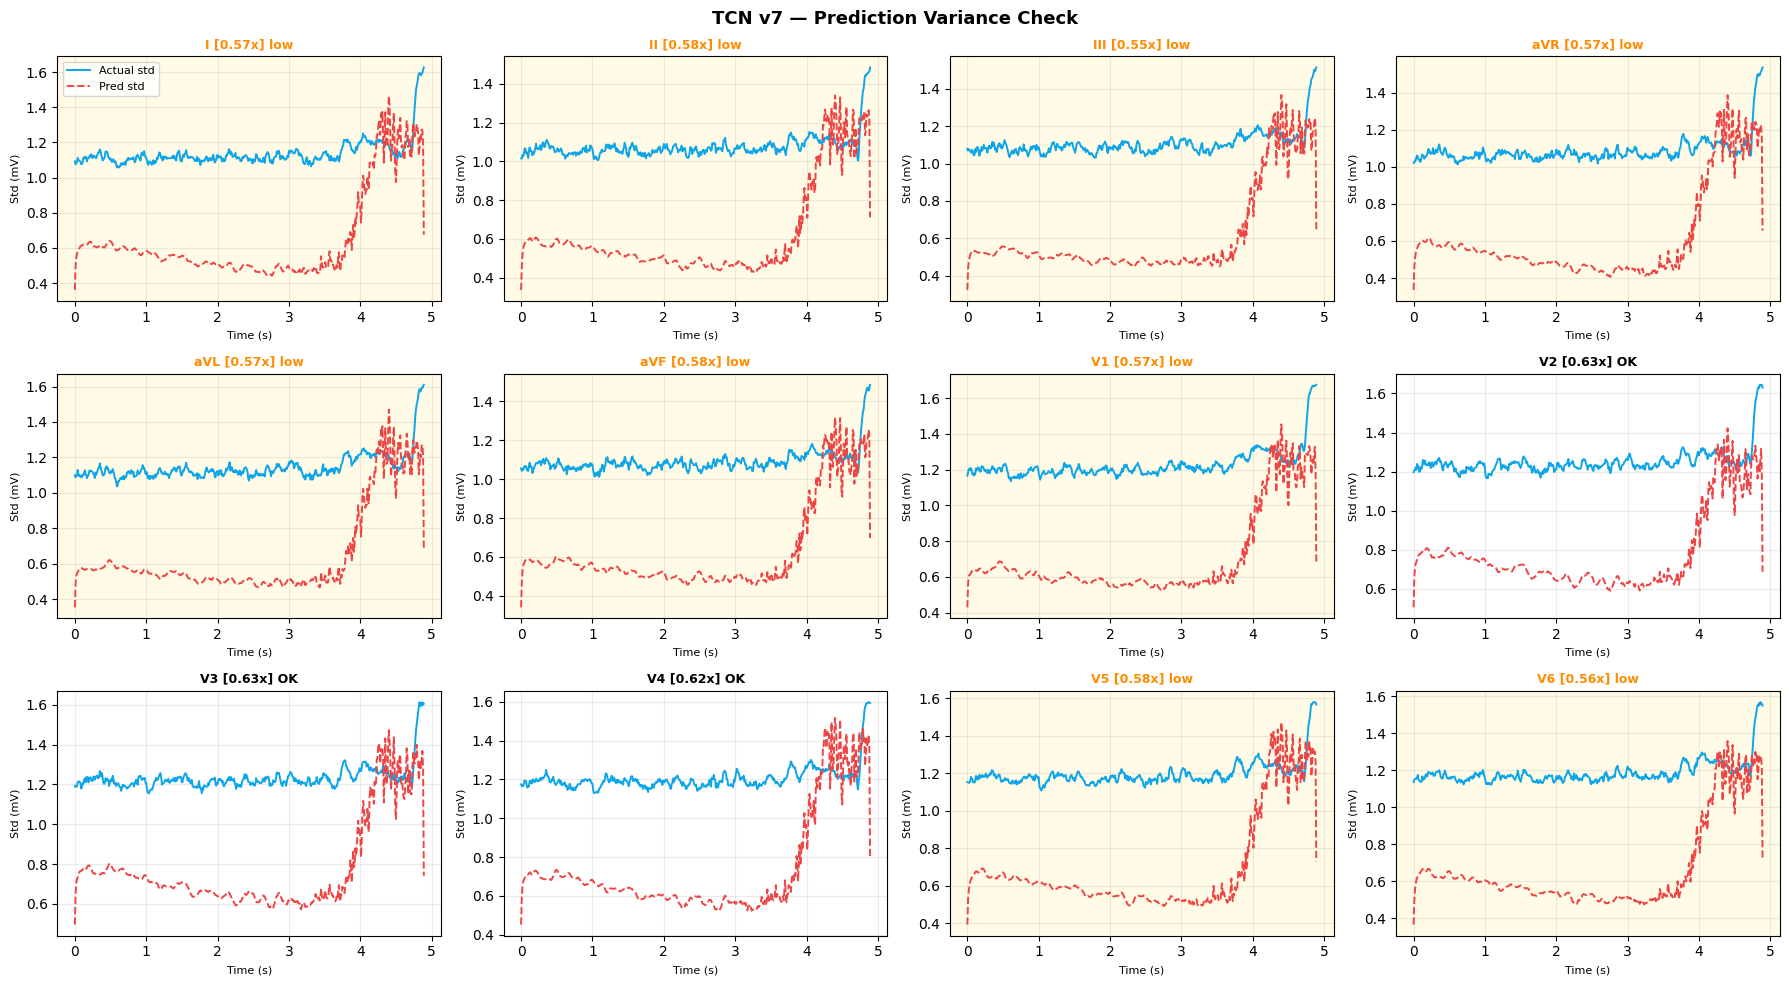

Low-variance: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V5', 'V6'] — extend epochs or raise GRAD_WEIGHT to 0.7


In [15]:
# CELL 14 — VARIANCE CHECK
pred_std = test_preds.std(axis=0)
true_std = test_targets.std(axis=0)
t_axis   = np.arange(HORIZON) / FS

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
flat_leads, low_leads = [], []
for i, (ax, name) in enumerate(zip(axes.flatten(), LEAD_NAMES)):
    ax.plot(t_axis, true_std[:,i], color='#0ea5e9', lw=1.4, label='Actual std')
    ax.plot(t_axis, pred_std[:,i], color='#ef4444', lw=1.4, label='Pred std', ls='--')
    ratio = pred_std[:,i].mean() / (true_std[:,i].mean() + 1e-9)
    ax.set_xlabel('Time (s)', fontsize=8); ax.set_ylabel('Std (mV)', fontsize=8)
    ax.grid(alpha=0.25)
    if i == 0: ax.legend(fontsize=8)
    if ratio < 0.3:
        ax.set_facecolor('#fff0f0')
        ax.set_title(f'{name} [{ratio:.2f}x] FLAT', color='red', fontweight='bold', fontsize=9)
        flat_leads.append(name)
    elif ratio < 0.6:
        ax.set_facecolor('#fffbe6')
        ax.set_title(f'{name} [{ratio:.2f}x] low', color='darkorange', fontweight='bold', fontsize=9)
        low_leads.append(name)
    else:
        ax.set_title(f'{name} [{ratio:.2f}x] OK', fontweight='bold', fontsize=9)

fig.suptitle('TCN v7 — Prediction Variance Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_variance_check.png'), dpi=150, bbox_inches='tight')
plt.show()

if flat_leads and len(flat_leads) == N_LEADS:
    print('ALL FLAT — check Cell 6 loss balance')
elif flat_leads:
    print(f'Flat: {flat_leads} — raise FFT_WEIGHT to 0.2 in Cell 6')
elif low_leads:
    print(f'Low-variance: {low_leads} — extend epochs or raise GRAD_WEIGHT to 0.7')
else:
    print(f'OK  overall ratio = {pred_std.mean()/true_std.mean():.2f}x')


In [16]:
# CELL 15 — SAVE RESULTS
results = dict(
    model='TCN_v11_FullPerLeadWeighted',
    horizon_s=HORIZON/FS, input_s=INPUT_LEN/FS,
    n_parameters=n_params,
    test_loss=float(test_loss),
    mae_per_lead=mae_per_lead, mae_macro=mae_macro,
    rmse_per_lead=rmse_per_lead, rmse_macro=rmse_macro,
    prd_per_lead=prd_per_lead, prd_macro=prd_macro,
    qrs_precision=float(prec), qrs_recall=float(rec), qrs_f1=float(f1),
    loss_config=dict(huber_delta=HUBER_DELTA, grad_huber=GRAD_HUBER,
                     grad_weight=GRAD_WEIGHT, fft_weight=FFT_WEIGHT,
                     hf_boost=HF_BOOST, hf_cutoff=HF_CUTOFF, fft_normalized=True),
    norm=dict(mu=NORM_MU, sigma=NORM_SIGMA),
    history=history, lead_names=LEAD_NAMES,
    test_preds=test_preds, test_targets=test_targets,
)
res_path = os.path.join(CKPT_DIR, 'TCN_v11_results.pkl')
with open(res_path, 'wb') as f:
    pickle.dump(results, f)

avg_ep = np.mean(history['epoch_secs'])
print(f'\n{"="*64}')
print(f'  TCN v11 FINAL')
print(f'{"="*64}')
print(f'  Architecture : TCN Enc-Dec (K=5, 4 blocks, skip connections) — unchanged')
print(f'  Loss         : {GRAD_HUBER}xHuber + {GRAD_WEIGHT}xGradL1 + {FFT_WEIGHT}xNormFFT  (Huber-dominant, matches CNN-LSTM v17)')
print(f'  Optimizer    : Adam(lr=1e-3) + ReduceLROnPlateau  (was AdamW + CAWR in v6)')
print(f'  Speed        : {avg_ep:.1f}s/epoch')
print(f'  Parameters   : {n_params:,}')
print(f'  Macro MAE    : {mae_macro:.6f} mV')
print(f'  Macro RMSE   : {rmse_macro:.6f} mV')
print(f'  Macro PRD    : {prd_macro:.2f}%   (v6 was 102.13%)')
print(f'  QRS F1       : {f1:.3f}   (v6 was 0.238)')
print(f'{"="*64}')
print(f'  Checkpoint : {CKPT_DIR}/TCN_v11_best.pt')
print(f'  Results    : {res_path}')
print('OK TCN v11 complete')



  TCN v11 FINAL
  Architecture : TCN Enc-Dec (K=5, 4 blocks, skip connections) — unchanged
  Loss         : 1.0xHuber + 0.1xGradL1 + 0.075xNormFFT  (Huber-dominant, matches CNN-LSTM v17)
  Optimizer    : Adam(lr=1e-3) + ReduceLROnPlateau  (was AdamW + CAWR in v6)
  Speed        : 73.6s/epoch
  Parameters   : 5,903,244
  Macro MAE    : 0.724955 mV
  Macro RMSE   : 1.175319 mV
  Macro PRD    : 100.37%   (v6 was 102.13%)
  QRS F1       : 0.310   (v6 was 0.238)
  Checkpoint : checkpoints/TCN_v11_best.pt
  Results    : checkpoints/TCN_v11_results.pkl
OK TCN v11 complete
